# BANK LOAN ANALYSIS REPORT

### 1. Portfolio Overview
The database contains 38,576 total loan applications recorded across 24 data columns. The primary financial activities span across the year 2021, culminating in December 2021.

## Import Libraries

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import numpy as np

In [ ]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\To Do excel\Bank_Loan_Project\financial_loan.csv")

### Metadata Of Data

In [24]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [6]:
print("No Of Rows: ", df.shape[0])

No Of Rows:  38576


In [31]:
print("No Of Rows: ", df.shape[1])

No Of Rows:  24


#### DataType

In [36]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [32]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Key Performance Indicators (KPIs)
Total Loan Applications: 38,576

Month-to-Date (MTD) Applications (Dec 2021): 4,314

Total Funded Amount: $435.76M

MTD Total Funded Amount (Dec 2021): $53.98M

Total Amount Received (Payments): $473.07M

MTD Total Amount Received (Dec 2021): $58.07M

Average Interest Rate: 12.05%

#### Total Loan Applications

In [25]:
total_loan_application = df['id'].count()
print("Total_loan_application: ", total_loan_application)

Total_loan_application:  38576


#### MTD Total Loan Applications

In [15]:
Latest_issue_date = df['issue_date'].max()
latest_year = Latest_issue_date.year
latest_mon = Latest_issue_date.month
mtd_filter = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_mon)]
mtd_loan_application = mtd_filter['id'].count()
print(f"MTD Total Loan Application (For {Latest_issue_date.strftime("%B %Y")}):, {mtd_loan_application}")

MTD Total Loan Application (For December 2021):, 4314


#### Total Funded Amount

In [31]:
tot_funded_amont = round((df['loan_amount'].sum())/1000000,2)
print(f'Total Funded Amount: ${tot_funded_amont}M')

Total Funded Amount: $435.76M


#### MTD Total Funded Amount

In [29]:
latest_date = df['issue_date'].max()
latest_year = latest_date.year
latest_mon = latest_date.month
mtd_funded_filter = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_mon)]
mtd_funded_amount =round((mtd_funded_filter['loan_amount'].sum())/1000000, 2)
print(f'MTD Total Funded Amount (For {latest_date.strftime("%B %Y")}): ${mtd_funded_amount}M')

MTD Total Funded Amount (For December 2021): $53.98M


#### Total Amount Received

In [33]:
tot_amnt_rcvd = round((df['total_payment'].sum())/1000000,2)
print(f'Total Amount Received : ${tot_amnt_rcvd}M')

Total Amount Received : $473.07M


In [37]:
latest_dt = df['issue_date'].max()
latst_yr = latest_dt.year
latst_mon = latest_dt.month
mtd_rcvd_filter = df[(df['issue_date'].dt.year == latst_yr) & (df['issue_date'].dt.month == latst_mon)]
mtd_amnt_rcvd = round((mtd_rcvd_filter['total_payment'].sum())/1000000,2)
print(f'MTD Total Amount Received (For {latest_date.strftime("%B %Y")}): ${mtd_amnt_rcvd}M')

MTD Total Amount Received (For December 2021): $58.07M


#### Average Interest Rate

In [43]:
avg_int_rt = round((df['int_rate'].mean())*100, 2)
print(f'Average Interest Rate: {avg_int_rt}%')

Average Interest Rate: 12.05%


#### Debt To Income Ratio

In [47]:
dti_ratio = round((df['dti'].mean()*100),2)
print(f'Average Debt To Income Ratio: {dti_ratio}%')

Average Debt To Income Ratio: 13.33%


### 2. Loan Quality Assessment
Loans are partitioned into performance tiers based on their current payoff status.

### A. Good Loans Performance (Fully Paid & Current)
Good loans represent the healthy portion of the portfolio where obligations are met consistently.

Total Applications: 33,243

Portfolio Share: 86.18%

Total Capital Funded: $370.22M

Total Capital Recovered: $435.79M

#### Good Loans Metrics

In [28]:
good_loans = df[(df['loan_status'].isin(['Fully Paid', 'Current']))]   # for goo loan
tot_loan_appl = df['id'].count()   # tot_loan_appl

gdloan_loan_appli = good_loans['id'].count()
gdloan_funded_amnt = round((good_loans['loan_amount'].sum())/1000000,2)
gdloan_amnt_rcvd = round((good_loans['total_payment'].sum())/1000000,2)
per_gdloan_appli =  round((gdloan_loan_appli/tot_loan_appl)*100,2)

print("Good Loan Total Application: ", gdloan_loan_appli)
print(f'Good Loan Total Funded Amount: ${gdloan_funded_amnt}M')
print(f'Good Loan Total Amount Received : ${gdloan_amnt_rcvd}M')
print(f'Percentage Of Good Loan Applications : {per_gdloan_appli}%')


Good Loan Total Application:  33243
Good Loan Total Funded Amount: $370.22M
Good Loan Total Amount Received : $435.79M
Percentage Of Good Loan Applications : 86.18%


### B. Bad Loans Performance (Charged Off)
Bad loans denote high-risk accounts that have defaulted, causing a net financial write-off.

Total Applications: 5,333

Portfolio Share: 13.82%

Total Capital Funded: $65.53M

Total Capital Recovered: $37.28M

#### Bad Loans Metrics

In [7]:
bad_loans = df[(df['loan_status'].isin(["Charged Off"]))]

Total_loan_application = df['id'].count()

bad_loan_appli = bad_loans['id'].count()
bd_loan_funded_amnt = round(bad_loans['loan_amount'].sum()/1000000,2)

bd_loan_amnt_rcvd = round(bad_loans['total_payment'].sum()/1000000,2)
per_bad_loan = round((bad_loan_appli/Total_loan_application)*100, 2)

print(f'Bad Loan Total Application: {bad_loan_appli}')
print(f'Bad Loan Total Funded Amount : ${bd_loan_funded_amnt}M ')
print(f'Bad Loan Total Amount Received: ${bd_loan_amnt_rcvd}M ')
print(f'Percentage Of Bad Loan Applications : {per_bad_loan}%')

Bad Loan Total Application: 5333
Bad Loan Total Funded Amount : $65.53M 
Bad Loan Total Amount Received: $37.28M 
Percentage Of Bad Loan Applications : 13.82%


#### Monthly Trends By Issue Date For Total Funded Amount

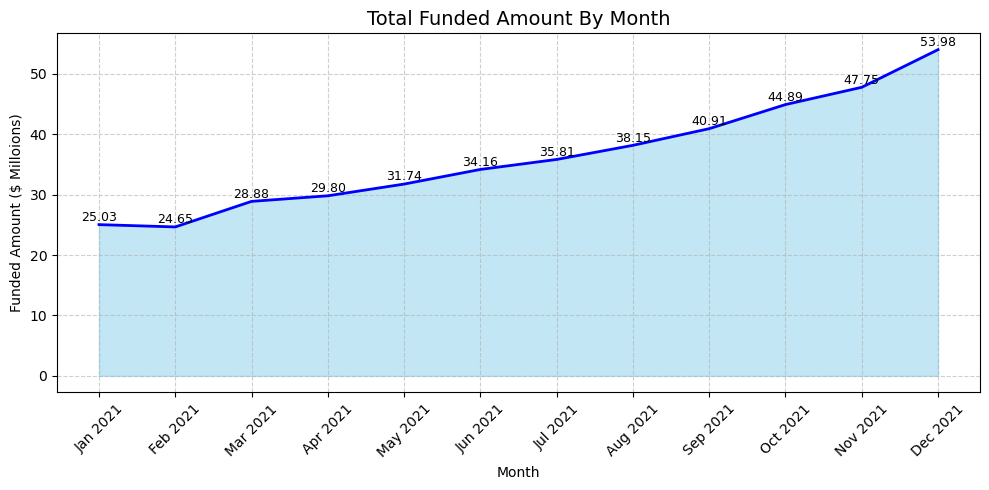

In [31]:
monthly_funded = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name = "Funded Amount In Millions"))   
plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['Funded Amount In Millions'],color='skyblue', alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['Funded Amount In Millions'], color='blue', linewidth=2)
for i, row in monthly_funded.iterrows():
    plt.text(i, row['Funded Amount In Millions']+ 0.1, f'{row['Funded Amount In Millions']:.2f}', ha='center', va ='bottom', fontsize=9, rotation =0, color='black')
plt.title('Total Funded Amount By Month', fontsize=14)
plt.xlabel("Month")
plt.ylabel("Funded Amount ($ Milloions)")
plt.xticks(ticks=range(len(monthly_funded)), labels=monthly_funded['month_name'], rotation =45)
plt.grid(True, linestyle= '--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Total Amount Received By Month

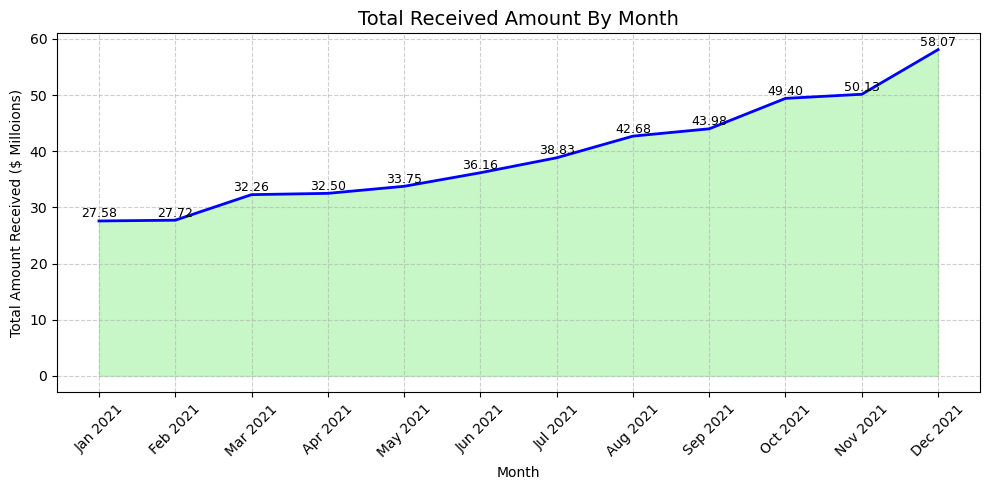

In [35]:
monthly_received = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name = 'Amount Received In Millions')
)
plt.figure(figsize=(10,5))
plt.fill_between(monthly_received['month_name'],monthly_received['Amount Received In Millions'],color='lightgreen', alpha=0.5)
plt.plot(monthly_received['month_name'],monthly_received['Amount Received In Millions'], color='blue', linewidth=2)
for i, row in monthly_received.iterrows():
    plt.text(i, row['Amount Received In Millions']+ 0.1, f'{row['Amount Received In Millions']:.2f}', ha='center', va ='bottom', fontsize=9, rotation =0, color='black')
plt.title('Total Received Amount By Month', fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Amount Received ($ Milloions)")
plt.xticks(ticks=range(len(monthly_received)), labels=monthly_received['month_name'], rotation =45)
plt.grid(True, linestyle= '--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Total Application By Month

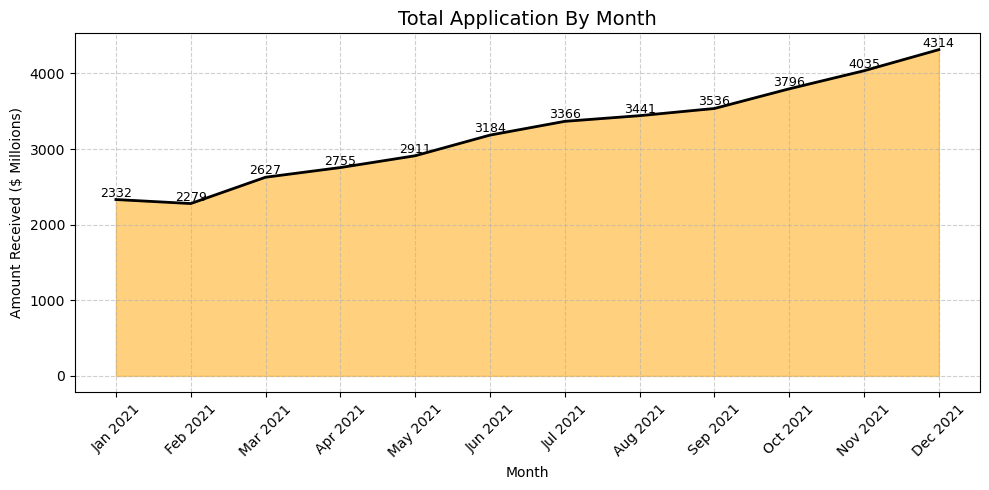

In [41]:
monthly_application = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .count()
    .reset_index(name = "Total Loan Application")
)
plt.figure(figsize=(10,5))
plt.fill_between(monthly_application['month_name'],monthly_application["Total Loan Application"],color='orange', alpha=0.5)
plt.plot(monthly_application['month_name'],monthly_application["Total Loan Application"], color='black', linewidth=2)
for i, row in monthly_application.iterrows():
    plt.text(i, row["Total Loan Application"]+ 0.1, f'{row["Total Loan Application"]:.0f}', ha='center', va ='bottom', fontsize=9, rotation =0, color='black')
plt.title('Total Application By Month', fontsize=14)
plt.xlabel("Month")
plt.ylabel("Amount Received ($ Milloions)")
plt.xticks(ticks=range(len(monthly_application)), labels=monthly_application['month_name'], rotation =45)
plt.grid(True, linestyle= '--', alpha=0.6)
plt.tight_layout()
plt.show()

### 3. Data Structure & Profile
The underlying dataset tracks key borrower traits and account variables:

Borrower Demographics & Employment: State location (address_state), Employment length (emp_length), Job title (emp_title), and Annual Income (annual_income).

Risk Metrics: Internal risk assessment grades (grade, sub_grade), verification status (verification_status), and Debt-to-Income metrics (dti).

Loan Details: Unique tracking details (id, member_id), declared application purpose (purpose), loan length (term), and interest configurations (int_rate, installment, loan_amount).

Chronology: Tracking critical operational timelines via issue_date, last_payment_date, next_payment_date, and last_credit_pull_date.

#### Regional Analysis By State For Total Funding

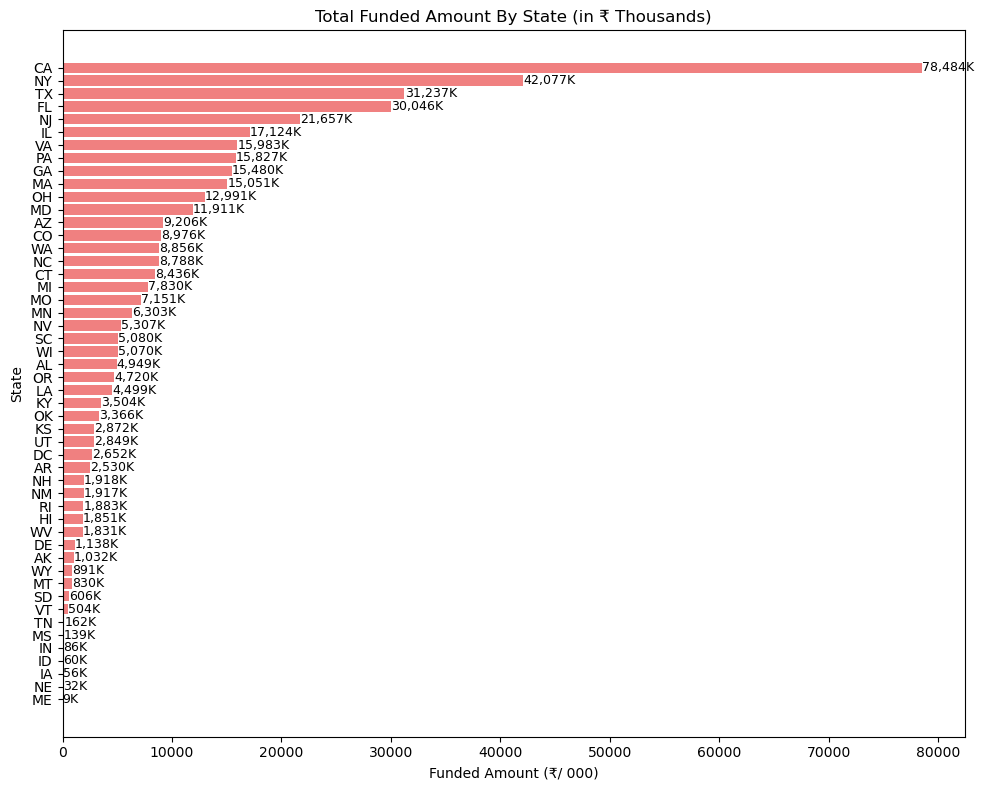

In [10]:
state_funding = df.groupby("address_state")['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding/1000
plt.figure(figsize=(10,8))
bars=plt.barh(state_funding_thousands.index, state_funding_thousands.values, color = 'lightcoral')
for bar in bars:
    width=bar.get_width()
    plt.text(width +10, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}K', va="center", fontsize=9)
plt.title("Total Funded Amount By State (in ₹ Thousands)")
plt.xlabel("Funded Amount (₹/ 000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()

#### Regional Analysis By State For Total Amount Received

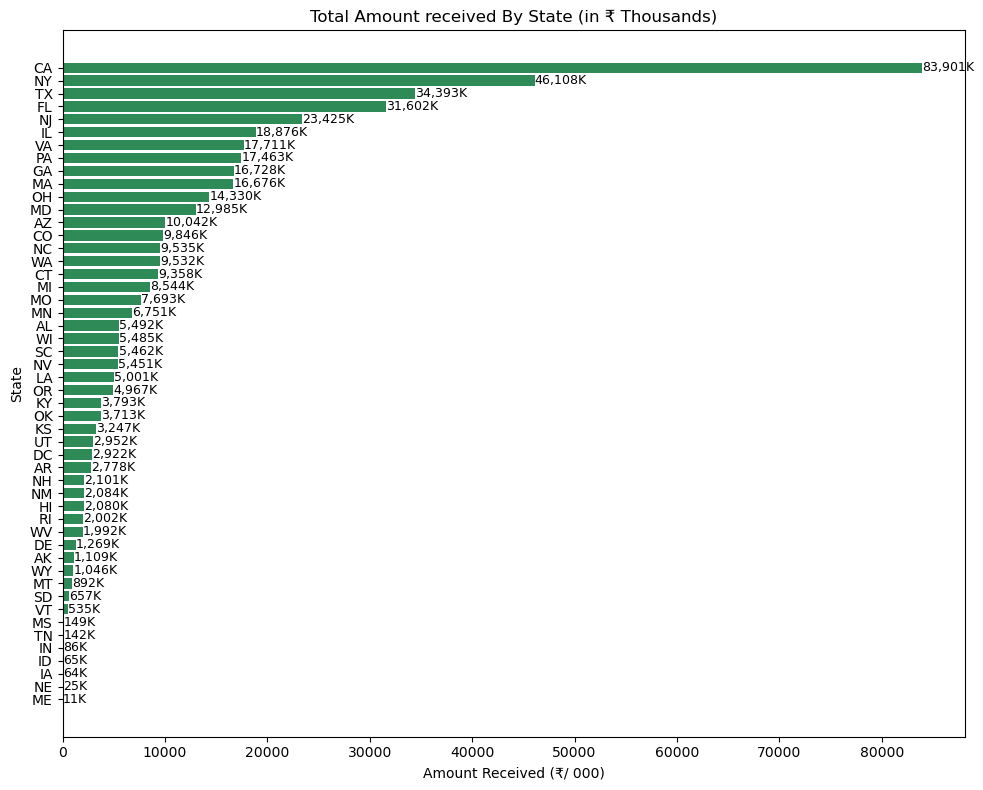

In [12]:
state_amnt_rcvd = df.groupby("address_state")['total_payment'].sum().sort_values(ascending=True)
state_mount_rcvd_thousands = state_amnt_rcvd/1000
plt.figure(figsize=(10,8))
bars=plt.barh(state_mount_rcvd_thousands.index, state_mount_rcvd_thousands.values, color = 'seagreen')
for bar in bars:
    width=bar.get_width()
    plt.text(width +10, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}K', va="center", fontsize=9)
plt.title("Total Amount received By State (in ₹ Thousands)")
plt.xlabel("Amount Received (₹/ 000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()

#### Loan term Analysis By Funded Amount

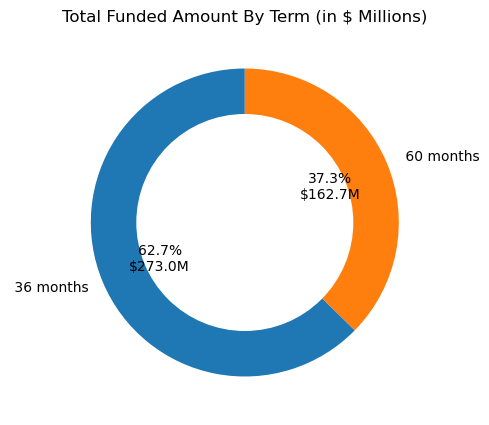

In [17]:
term_funding_millions = df.groupby('term')['loan_amount'].sum()/1000000
plt.figure(figsize= (5,5))
plt.pie(
    term_funding_millions,
    labels = term_funding_millions.index,
    autopct = lambda p:f'{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M',
    startangle =90,
    wedgeprops={'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70, color= 'white'))
plt.title("Total Funded Amount By Term (in $ Millions)")
plt.show()

#### Total Funded Amount By Employee Length

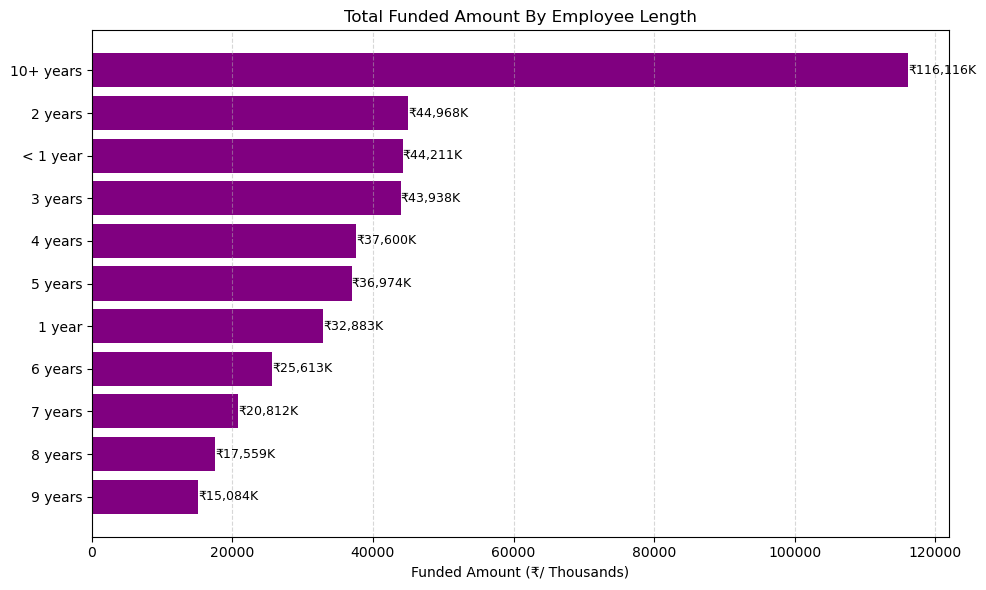

In [23]:
emp_length_byfunding = df.groupby("emp_length")['loan_amount'].sum().sort_values()/1000
plt.figure(figsize= (10,6))
bars = plt.barh(emp_length_byfunding.index, emp_length_byfunding, color='purple')
for bar in bars:
    width=bar.get_width()
    plt.text(width +5, bar.get_y() + bar.get_height()/2,
            f'₹{width:,.0f}K', va="center", fontsize=9)
plt.title("Total Funded Amount By Employee Length")
plt.xlabel("Funded Amount (₹/ Thousands)")
plt.grid(axis= 'x', linestyle= '--', alpha = 0.5 )
plt.tight_layout()
plt.show()

#### Loan Purpose By Total Funded Amount

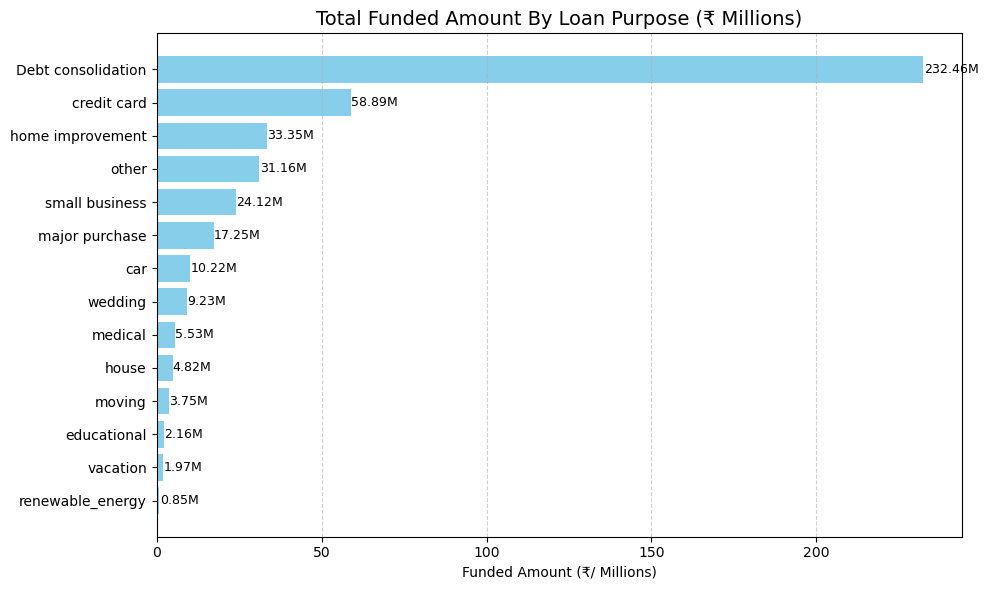

In [29]:
loan_purpose_funding = df.groupby("purpose")['loan_amount'].sum().sort_values()/1000000

plt.figure(figsize= (10,6))
bars = plt.barh(loan_purpose_funding.index, loan_purpose_funding.values, color='skyblue')
for bar in bars:
    width=bar.get_width()
    plt.text(width +0.1, bar.get_y() + bar.get_height()/2,
            f'{width:,.2f}M', va="center", fontsize=9)
plt.title("Total Funded Amount By Loan Purpose (₹ Millions)", fontsize=14)
plt.xlabel("Funded Amount (₹/ Millions)")
plt.grid(axis= 'x', linestyle= '--', alpha = 0.6 )
plt.tight_layout()
plt.show()

#### Home Ownership By Total Funded Amount

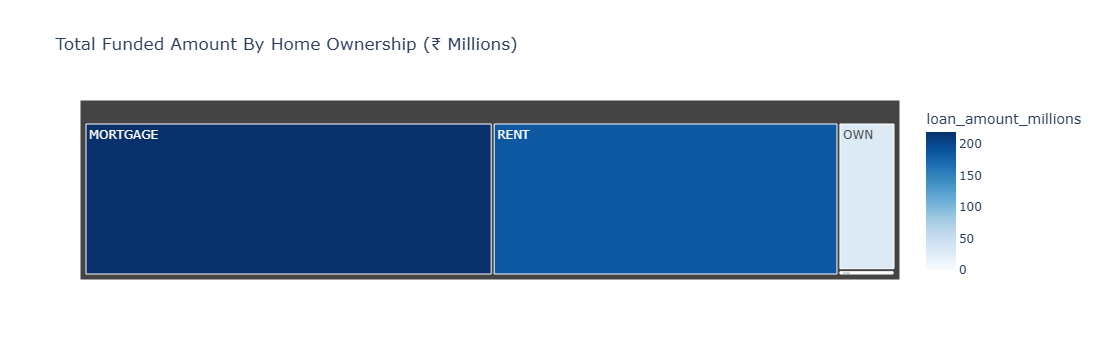

In [44]:
home_funding = df.groupby("home_ownership")['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount']/1000000
fig = px.treemap(
    home_funding,
    path = ["home_ownership"],
    values = 'loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale= 'Blues',
    title= "Total Funded Amount By Home Ownership (₹ Millions)" 
)
fig.show()

#### Home Ownership By Total Amount Received

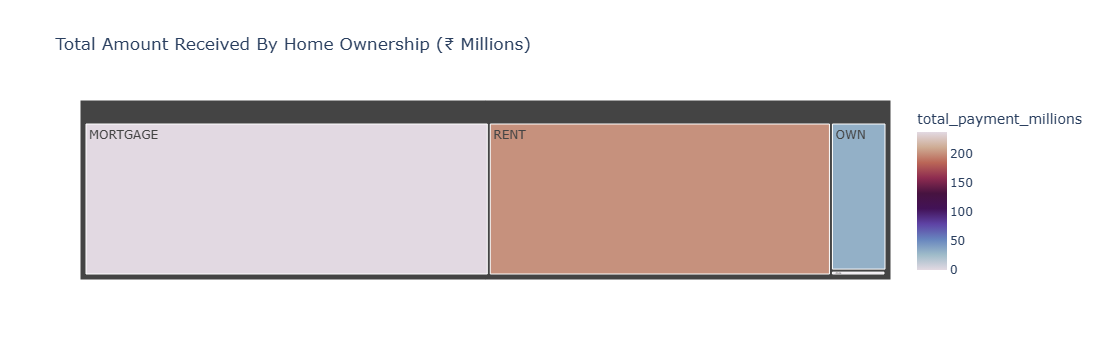

In [48]:
home_amnt_rcvd = df.groupby("home_ownership")['total_payment'].sum().reset_index()
home_amnt_rcvd['total_payment_millions'] = home_amnt_rcvd['total_payment']/1000000
fig = px.treemap(
    home_amnt_rcvd,
    path = ["home_ownership"],
    values = 'total_payment_millions',
    color = 'total_payment_millions',
    color_continuous_scale= 'twilight',
    title= "Total Amount Received By Home Ownership (₹ Millions)" 
)
fig.show()

#### Home Ownership By Total  Loan Application

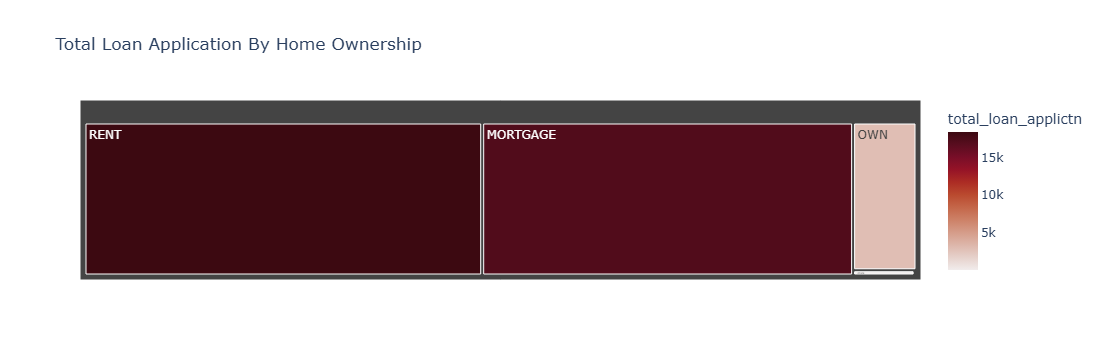

In [58]:
home_byapplication = df.groupby("home_ownership")['id'].count().reset_index()
home_byapplication['total_loan_applictn'] = home_byapplication['id']
fig = px.treemap(
    home_byapplication,
    path = ["home_ownership"],
    values = 'total_loan_applictn',
    color = 'total_loan_applictn',
    color_continuous_scale= 'amp',
    title= "Total Loan Application By Home Ownership" 
)
fig.show()